(891, 15)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
age            19.865320
embarked        0.224467
deck           77.216611
embark_to

C:\Users\shara\AppData\Local\Temp\ipykernel_13584\3874175252.py:20: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean["age"].fillna(df_clean["age"].median(), inplace=True)


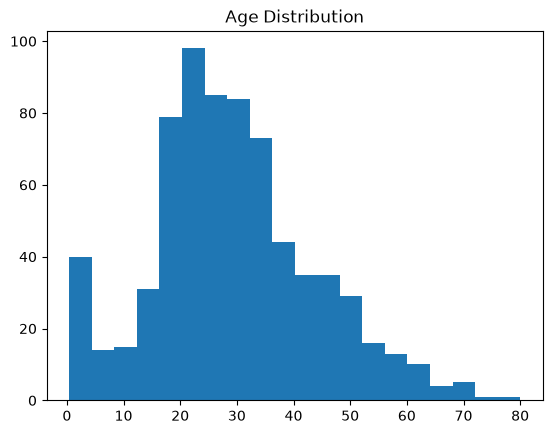

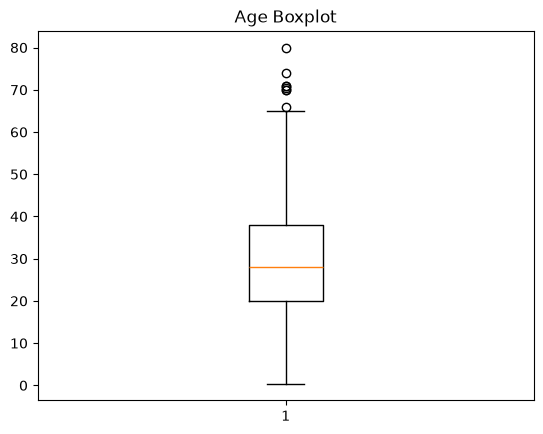

Fare outliers: 114
Survival by sex:
 sex
female    0.740385
male      0.188908
Name: survived, dtype: float64
Survival by pclass:
 pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64
Survival by sex+pclass:
 sex     pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64


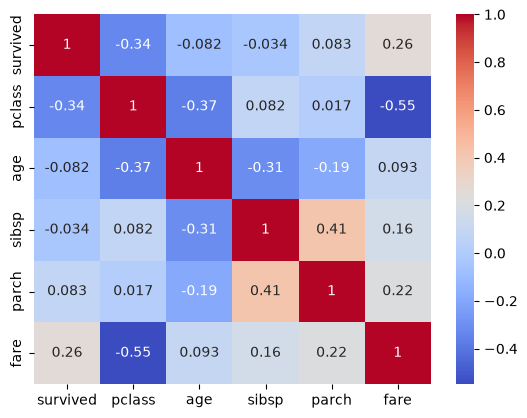

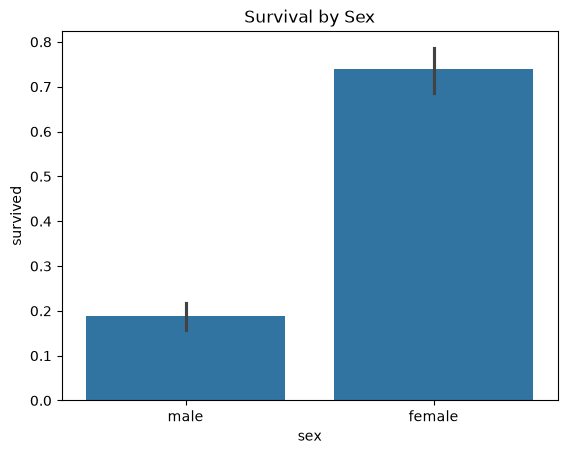

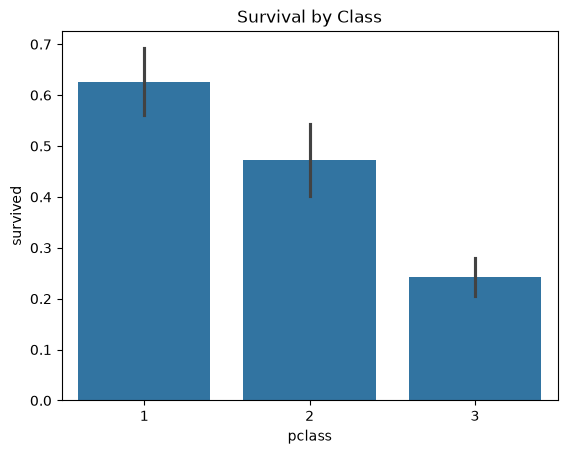

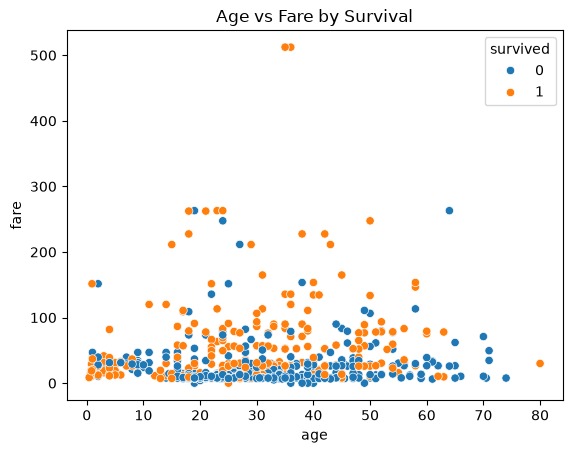

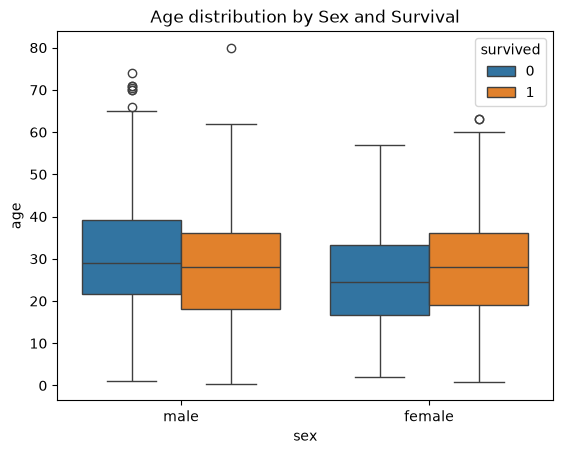

              age         age_z        fare        fare_z
count  712.000000  7.120000e+02  889.000000  8.890000e+02
mean    29.642093  2.943962e-16   32.096681  1.398706e-16
std     14.492933  1.000703e+00   49.697504  1.000563e+00
min      0.420000 -2.017717e+00    0.000000 -6.462044e-01
25%     20.000000 -6.657639e-01    7.895800 -4.872378e-01
50%     28.000000 -1.133826e-01   14.454200 -3.551972e-01
75%     38.000000  5.770939e-01   31.000000 -2.207954e-02
max     80.000000  3.477095e+00  512.329200  9.668551e+00


In [3]:
# Cell 1: Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cell 2: Load Titanic dataset once
df = sns.load_dataset("titanic")
df.to_csv("titanic.csv", index=False)  # offline fallback
print(df.shape)
df.info()
df.describe()

# Cell 3: Missing values percentage
missing = df.isnull().mean() * 100
print(missing[missing > 0])

# Cell 4: Handle missing values (threshold rule)
# Example: drop rows if <5%, impute if 5–30%, drop/encode if >30%
df_clean = df.copy()
df_clean["age"].fillna(df_clean["age"].median(), inplace=True)
df_clean.dropna(subset=["embarked"], inplace=True)

# Cell 5: Univariate analysis
plt.hist(df_clean["age"], bins=20); plt.title("Age Distribution"); plt.show()
plt.boxplot(df_clean["age"].dropna()); plt.title("Age Boxplot"); plt.show()

# Outlier detection using IQR
Q1, Q3 = df_clean["fare"].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = ((df_clean["fare"] < Q1 - 1.5*IQR) | (df_clean["fare"] > Q3 + 1.5*IQR)).sum()
print("Fare outliers:", outliers)

# Cell 6: Bivariate survival analysis
print("Survival by sex:\n", df_clean.groupby("sex")["survived"].mean())
print("Survival by pclass:\n", df_clean.groupby("pclass")["survived"].mean())
print("Survival by sex+pclass:\n", df_clean.groupby(["sex","pclass"])["survived"].mean())

# Cell 7: Correlation matrix
cols = ["survived","pclass","age","sibsp","parch","fare"]
corr = df_clean[cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

# Cell 8: Multivariate charts (examples)
sns.barplot(x="sex", y="survived", data=df_clean)
plt.title("Survival by Sex"); plt.show()

sns.barplot(x="pclass", y="survived", data=df_clean)
plt.title("Survival by Class"); plt.show()

sns.scatterplot(x="age", y="fare", hue="survived", data=df_clean)
plt.title("Age vs Fare by Survival"); plt.show()

sns.boxplot(x="sex", y="age", hue="survived", data=df_clean)
plt.title("Age distribution by Sex and Survival"); plt.show()

# Cell 9: Standardization check
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_clean[["age_z","fare_z"]] = scaler.fit_transform(df_clean[["age","fare"]])
print(df_clean[["age","age_z","fare","fare_z"]].describe())
